# 🌽 DenseNet121 — Corn Leaf Disease Detection Trainer
> **Framework:** PyTorch 2.x | **Model:** DenseNet121 (Transfer Learning + Fine-tuning)  
> **Dataset:** Corn Leaf Disease (PlantVillage atau custom) | **Task:** Multi-class Classification

---
### 📋 Daftar Cell
| # | Cell | Keterangan |
|---|------|-----------|
| 1 | Cek Lingkungan | Verifikasi GPU & library |
| 2 | Install Library | Pastikan dependency terinstal |
| 3 | Import | Import semua modul |
| 4 | ⚙️ Konfigurasi Dataset | **Ubah di sini** sebelum mulai |
| 5 | Load Dataset Kaggle | Jalankan jika sumber = Kaggle |
| 6 | Mount Google Drive | Jalankan jika sumber = Drive |
| 7 | Siapkan Dataset | Split train/val/test otomatis |
| 8 | Eksplorasi Dataset | Statistik & sampel gambar |
| 9 | ⚙️ Konfigurasi Hyperparameter | **Ubah di sini** sesuai kebutuhan |
| 10 | Transform & DataLoader | Augmentasi + loader |
| 11 | Bangun Model | DenseNet121 custom head |
| 12 | Utilitas Training | Checkpoint & helper functions |
| 13 | Loop Training | Training dengan live logs |
| 14 | Mulai / Lanjutkan Training | **Jalankan untuk training** |
| 15 | Visualisasi History | Kurva loss & accuracy |
| 16 | Evaluasi Model | Confusion matrix & report |
| 17 | Simpan Model Akhir | Export ke berbagai format |
| 18 | ⚙️ Konfigurasi Inferensi | **Ubah di sini** sebelum inferensi |
| 19 | Inferensi Gambar Baru | Deteksi penyakit pada gambar baru |

In [1]:
# ═══════════════════════════════════════════════════
# CELL 1 — Cek Lingkungan & GPU
# ═══════════════════════════════════════════════════
import subprocess, sys, platform
import torch
import torchvision

print("=" * 60)
print("🖥️  INFORMASI LINGKUNGAN")
print("=" * 60)
print(f"Python       : {sys.version.split()[0]}")
print(f"PyTorch      : {torch.__version__}")
print(f"Torchvision  : {torchvision.__version__}")
print(f"CUDA tersedia: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu_count = torch.cuda.device_count()
    print(f"GPU Count    : {gpu_count}")
    for i in range(gpu_count):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU [{i}]      : {props.name}")
        print(f"VRAM [{i}]     : {props.total_memory / 1e9:.2f} GB")
    print(f"CUDA Version : {torch.version.cuda}")
else:
    print()
    print("⚠️  WARNING: GPU tidak aktif!")
    print("   Aktifkan GPU: Runtime → Change runtime type → T4 GPU")
    print("   Training di CPU akan SANGAT lambat.")

print("=" * 60)

🖥️  INFORMASI LINGKUNGAN
Python       : 3.12.13
PyTorch      : 2.11.0+cu128
Torchvision  : 0.26.0+cu128
CUDA tersedia: True
GPU Count    : 1
GPU [0]      : Tesla T4
VRAM [0]     : 15.64 GB
CUDA Version : 12.8


In [2]:
# ═══════════════════════════════════════════════════
# CELL 2 — Install Library Tambahan
# ═══════════════════════════════════════════════════
# Library utama (torch, torchvision) sudah ada di Colab
# Instal yang belum tersedia:
%pip install -q kaggle scikit-learn seaborn matplotlib tqdm Pillow
print("✅ Semua library siap.")

✅ Semua library siap.


In [3]:
# ═══════════════════════════════════════════════════
# CELL 3 — Import Semua Modul
# ═══════════════════════════════════════════════════
import os, sys, json, time, copy, shutil, random, warnings
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from torch.optim.lr_scheduler import (
    CosineAnnealingLR, ReduceLROnPlateau, StepLR, OneCycleLR
)

import torchvision
from torchvision import datasets, transforms
from torchvision.models import densenet121, DenseNet121_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")


# ── Reproducibility ────────────────────────────────────────
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Device aktif: {DEVICE}")
print(f"✅ Semua modul berhasil diimport.")

🔧 Device aktif: cuda
✅ Semua modul berhasil diimport.


## ⚙️ KONFIGURASI DATASET
> **Atur variabel di bawah sebelum menjalankan cell dataset**

| Variabel | Keterangan |
|----------|-----------|
| `DATASET_SOURCE` | `'kaggle'` atau `'drive'` |
| `DRIVE_MODE` | `'split_folders'` (sudah ada train/test) atau `'single_folder'` (satu folder, akan di-split) |
| `SPLIT_RATIO` | Proporsi test set, misal `0.2` = 20% |
| `SPLIT_VALID_RATIO` | Proporsi val dari total dataset, misal `0.1` = 10% |

In [4]:
# ═══════════════════════════════════════════════════
# CELL 4 — Konfigurasi Dataset
# ═══════════════════════════════════════════════════
# ── Sumber Dataset ─────────────────────────────────
DATASET_SOURCE = 'drive'     # 'kaggle' | 'drive'

# ── Kaggle ─────────────────────────────────────────
KAGGLE_DATASET   = 'vipoooool/new-plant-diseases-dataset'
#                  ^^ Ganti dengan username/nama-dataset di Kaggle
KAGGLE_UNZIP_DIR = '/content/kaggle_dataset'

# ── Google Drive ───────────────────────────────────
# Mode 'split_folders' → dataset sudah terbagi train & test/valid
DRIVE_MODE       = 'split_folders'  # 'split_folders' | 'single_folder'

# Jika DRIVE_MODE = 'split_folders':
DRIVE_TRAIN_DIR  = '/content/drive/MyDrive/dataset_daun_jagung/train'
DRIVE_TEST_DIR   = '/content/drive/MyDrive/dataset_daun_jagung/val'
DRIVE_VALID_DIR  = ''   # Kosongkan jika tidak ada folder validasi terpisah

# Jika DRIVE_MODE = 'single_folder':
DRIVE_SINGLE_DIR = '/content/drive/MyDrive/datasets/corn'

# ── Split Ratio (untuk 'single_folder' atau auto-split) ──
SPLIT_TEST_RATIO  = 0.20   # 20% → test
SPLIT_VALID_RATIO = 0.10   # 10% → validasi (dari total dataset)

# ── Output ─────────────────────────────────────────
OUTPUT_DIR      = '/content/output'
CHECKPOINT_DIR  = f'{OUTPUT_DIR}/checkpoints'
os.makedirs(OUTPUT_DIR,     exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("✅ Konfigurasi dataset tersimpan:")
print(f"   Sumber     : {DATASET_SOURCE.upper()}")
print(f"   Drive mode : {DRIVE_MODE}")
print(f"   Output dir : {OUTPUT_DIR}")

✅ Konfigurasi dataset tersimpan:
   Sumber     : DRIVE
   Drive mode : split_folders
   Output dir : /content/output


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 5 — Load Dataset dari Kaggle
# ═══════════════════════════════════════════════════
# ⚠️  Jalankan HANYA jika DATASET_SOURCE == 'kaggle'
if DATASET_SOURCE == 'kaggle':
    from google.colab import files

    print("📂 Upload file kaggle.json")
    print("   (Diperoleh dari: https://www.kaggle.com/settings → API → Create New Token)")
    uploaded = files.upload()

    kaggle_dir = Path('/root/.config/kaggle')
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json = kaggle_dir / 'kaggle.json'

    if 'kaggle.json' in uploaded:
        kaggle_json.write_bytes(uploaded['kaggle.json'])
        kaggle_json.chmod(0o600)
        print("✅ kaggle.json dikonfigurasi.")
    else:
        raise FileNotFoundError("❌ File kaggle.json tidak ditemukan dalam upload!")

    # Download & unzip
    os.makedirs(KAGGLE_UNZIP_DIR, exist_ok=True)
    print(f"\n📥 Mendownload: {KAGGLE_DATASET} ...")
    ret = os.system(f"kaggle datasets download -d {KAGGLE_DATASET} -p {KAGGLE_UNZIP_DIR} --unzip -q")
    if ret != 0:
        print("❌ Download gagal. Periksa nama dataset dan koneksi internet.")
    else:
        print(f"✅ Download selesai → {KAGGLE_UNZIP_DIR}")
        print("\n📁 Isi folder:")
        for p in sorted(Path(KAGGLE_UNZIP_DIR).iterdir()):
            print(f"   {'[DIR] ' if p.is_dir() else '      '}{p.name}")
else:
    print(f"ℹ️  DATASET_SOURCE = '{DATASET_SOURCE}' → cell ini dilewati.")

In [5]:
# ═══════════════════════════════════════════════════
# CELL 6 — Mount Google Drive
# ═══════════════════════════════════════════════════
# ⚠️  Jalankan HANYA jika DATASET_SOURCE == 'drive'
if DATASET_SOURCE == 'drive':
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print("✅ Google Drive berhasil di-mount.")

    if DRIVE_MODE == 'split_folders':
        for name, d in [('Train', DRIVE_TRAIN_DIR), ('Test', DRIVE_TEST_DIR)]:
            if d and os.path.exists(d):
                n = sum(1 for _ in Path(d).rglob('*') if _.is_file())
                print(f"   ✅ {name:5s}: {d}  ({n} file)")
            else:
                print(f"   ❌ {name:5s}: Tidak ditemukan → {d}")
        if DRIVE_VALID_DIR and os.path.exists(DRIVE_VALID_DIR):
            n = sum(1 for _ in Path(DRIVE_VALID_DIR).rglob('*') if _.is_file())
            print(f"   ✅ Valid: {DRIVE_VALID_DIR}  ({n} file)")
    else:
        if os.path.exists(DRIVE_SINGLE_DIR):
            n = sum(1 for _ in Path(DRIVE_SINGLE_DIR).rglob('*') if _.is_file())
            print(f"   ✅ Dataset folder: {DRIVE_SINGLE_DIR}  ({n} file total)")
        else:
            print(f"   ❌ Folder tidak ditemukan: {DRIVE_SINGLE_DIR}")
else:
    print(f"ℹ️  DATASET_SOURCE = '{DATASET_SOURCE}' → cell ini dilewati.")

Mounted at /content/drive
✅ Google Drive berhasil di-mount.
   ✅ Train: /content/drive/MyDrive/dataset_daun_jagung/train  (11504 file)
   ✅ Test : /content/drive/MyDrive/dataset_daun_jagung/val  (1829 file)


In [6]:
# ═══════════════════════════════════════════════════
# CELL 7 — Siapkan & Resolve Path Dataset
# ═══════════════════════════════════════════════════
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp', '.JPG', '.JPEG', '.PNG'}


def _count_images(folder: Path) -> int:
    return sum(1 for f in folder.rglob('*') if f.suffix in IMG_EXTS)


def _split_single_folder(source_dir: Path,
                          test_ratio: float,
                          valid_ratio: float,
                          split_base: Path = Path('/content/dataset_split')):
    '''
    Split sebuah folder (dengan subfolder kelas) ke train / val / test
    menggunakan sklearn train_test_split.
    Returns: (train_dir, val_dir_or_None, test_dir)
    '''
    train_dir = split_base / 'train'
    test_dir  = split_base / 'test'
    val_dir   = split_base / 'val' if valid_ratio > 0 else None

    # Jika split sudah ada, skip
    if split_base.exists() and _count_images(split_base) > 0:
        print("ℹ️  Folder split sudah ada, digunakan langsung.")
        return str(train_dir), str(val_dir) if val_dir else None, str(test_dir)

    classes = sorted([d.name for d in source_dir.iterdir() if d.is_dir()])
    print(f"   Kelas ditemukan: {classes}")

    for cls in classes:
        imgs = sorted([
            f for f in (source_dir / cls).iterdir()
            if f.suffix in IMG_EXTS
        ])
        if not imgs:
            print(f"   ⚠️  [{cls}] Tidak ada gambar, dilewati.")
            continue

        # 1. Split test
        train_imgs, test_imgs = train_test_split(
            imgs, test_size=test_ratio, random_state=42, shuffle=True
        )

        # 2. Split val dari sisa train
        val_imgs = []
        if valid_ratio > 0:
            val_from_train = valid_ratio / (1.0 - test_ratio)
            train_imgs, val_imgs = train_test_split(
                train_imgs, test_size=val_from_train, random_state=42
            )

        # 3. Copy file
        for img in train_imgs:
            dst = train_dir / cls / img.name
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(img, dst)
        for img in test_imgs:
            dst = test_dir / cls / img.name
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(img, dst)
        if val_imgs:
            for img in val_imgs:
                dst = val_dir / cls / img.name
                dst.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(img, dst)

        print(f"   [{cls}] Total:{len(imgs)}  Train:{len(train_imgs)}"
              + (f"  Val:{len(val_imgs)}" if val_imgs else "")
              + f"  Test:{len(test_imgs)}")

    return str(train_dir), str(val_dir) if val_dir else None, str(test_dir)


# ── Resolve path berdasarkan config ─────────────────────────
TRAIN_DIR = None
VAL_DIR   = None
TEST_DIR  = None

if DATASET_SOURCE == 'drive':
    if DRIVE_MODE == 'split_folders':
        TRAIN_DIR = DRIVE_TRAIN_DIR
        TEST_DIR  = DRIVE_TEST_DIR
        VAL_DIR   = DRIVE_VALID_DIR if DRIVE_VALID_DIR and os.path.exists(DRIVE_VALID_DIR) else None
    else:   # single_folder
        print(f"🔪 Melakukan train/val/test split dari: {DRIVE_SINGLE_DIR}")
        TRAIN_DIR, VAL_DIR, TEST_DIR = _split_single_folder(
            Path(DRIVE_SINGLE_DIR),
            test_ratio=SPLIT_TEST_RATIO,
            valid_ratio=SPLIT_VALID_RATIO,
        )

elif DATASET_SOURCE == 'kaggle':
    kaggle_base = Path(KAGGLE_UNZIP_DIR)
    train_cands = list(kaggle_base.rglob('train'))
    test_cands  = list(kaggle_base.rglob('test')) + list(kaggle_base.rglob('valid'))
    val_cands   = list(kaggle_base.rglob('val')) + list(kaggle_base.rglob('valid'))

    if train_cands and test_cands:
        TRAIN_DIR = str(next(d for d in train_cands if d.is_dir()))
        TEST_DIR  = str(next(d for d in test_cands  if d.is_dir()))
        VAL_DIR   = str(next(d for d in val_cands   if d.is_dir())) if val_cands else None
        print("✅ Auto-detected split folders dari Kaggle dataset.")
    else:
        print("⚠️  Struktur split tidak ditemukan → melakukan split manual.")
        TRAIN_DIR, VAL_DIR, TEST_DIR = _split_single_folder(
            kaggle_base,
            test_ratio=SPLIT_TEST_RATIO,
            valid_ratio=SPLIT_VALID_RATIO,
        )

# ── Verifikasi ──────────────────────────────────────────────
print("\n📁 Path Dataset:")
for name, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    if d:
        n = _count_images(Path(d)) if os.path.exists(d) else 0
        status = '✅' if n > 0 else '❌'
        print(f"   {status} {name:5s}: {d}  ({n} gambar)")

assert TRAIN_DIR and os.path.exists(TRAIN_DIR), "TRAIN_DIR tidak valid!"
assert TEST_DIR  and os.path.exists(TEST_DIR),  "TEST_DIR tidak valid!"
print("\n✅ Path dataset telah diverifikasi.")


📁 Path Dataset:
   ✅ Train: /content/drive/MyDrive/dataset_daun_jagung/train  (11504 gambar)
   ✅ Test : /content/drive/MyDrive/dataset_daun_jagung/val  (1829 gambar)

✅ Path dataset telah diverifikasi.


📊 EKSPLORASI DATASET

🏷️  Kelas (4 kelas):
   [0] Bercak_Daun
   [1] Hawar_Daun
   [2] Karat_Daun
   [3] Sehat

Split   Bercak_Daun    Hawar_Daun     Karat_Daun     Sehat             TOTAL
----------------------------------------------------------------------------
Train   2216           3054           3213           3021              11504
Test    410            477            477            465                1829


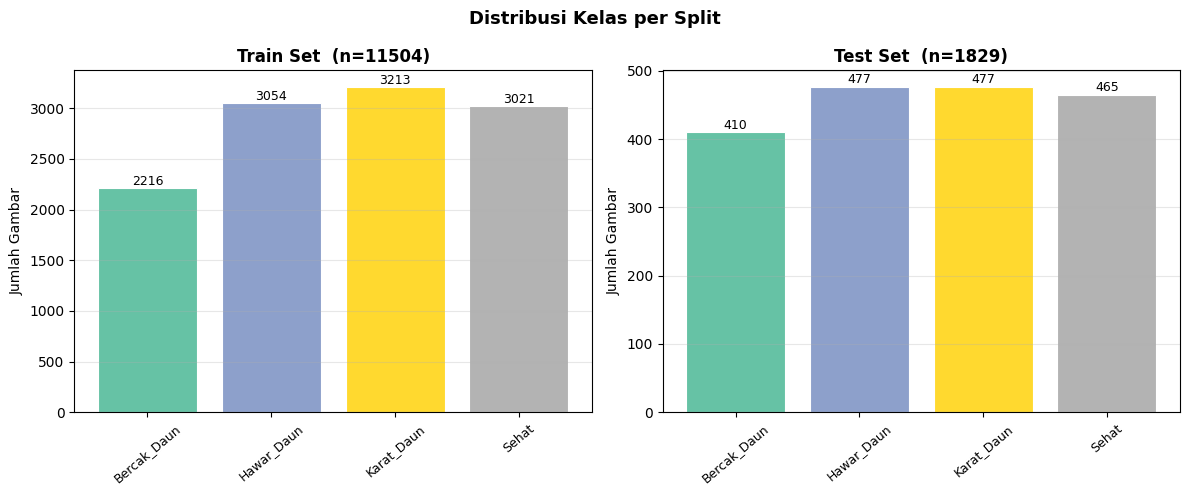

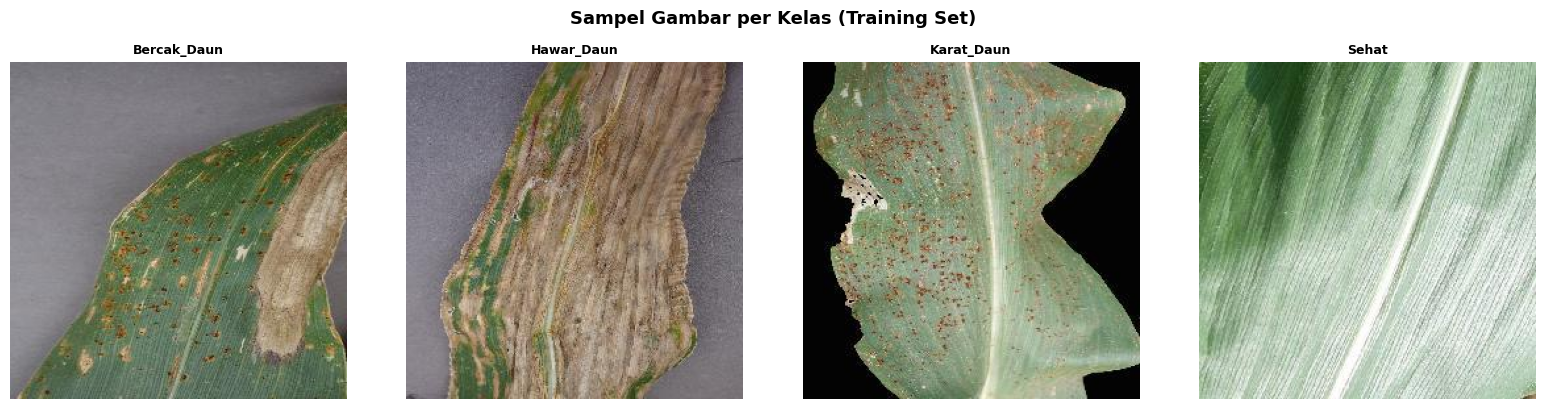


✅ NUM_CLASSES = 4  → ['Bercak_Daun', 'Hawar_Daun', 'Karat_Daun', 'Sehat']


In [7]:
# ═══════════════════════════════════════════════════
# CELL 8 — Eksplorasi Dataset
# ═══════════════════════════════════════════════════
def explore_dataset(train_dir, test_dir, val_dir=None, output_dir=OUTPUT_DIR):
    '''Statistik jumlah gambar per kelas + visualisasi.'''
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp',
                '.JPG', '.JPEG', '.PNG'}

    split_dirs = {'Train': train_dir, 'Test': test_dir}
    if val_dir and os.path.exists(val_dir):
        split_dirs['Val'] = val_dir

    classes = sorted([d.name for d in Path(train_dir).iterdir() if d.is_dir()])
    print("=" * 70)
    print("📊 EKSPLORASI DATASET")
    print("=" * 70)
    print(f"\n🏷️  Kelas ({len(classes)} kelas):")
    for i, c in enumerate(classes):
        print(f"   [{i}] {c}")

    # ── Tabel statistik ─────────────────────────────────────
    header = f"{'Split':<8}" + "".join(f"{c[:14]:<15}" for c in classes) + f"{'TOTAL':>8}"
    print(f"\n{header}")
    print("-" * len(header))

    stats = {}
    for sname, sdir in split_dirs.items():
        counts = []
        for cls in classes:
            p = Path(sdir) / cls
            n = len([f for f in p.iterdir() if f.suffix in IMG_EXTS]) if p.exists() else 0
            counts.append(n)
        total = sum(counts)
        stats[sname] = {'counts': counts, 'total': total}
        row = f"{sname:<8}" + "".join(f"{c:<15}" for c in counts) + f"{total:>8}"
        print(row)

    # ── Bar chart distribusi ─────────────────────────────────
    n_splits = len(split_dirs)
    fig, axes = plt.subplots(1, n_splits, figsize=(6 * n_splits, 5))
    if n_splits == 1:
        axes = [axes]
    colors = plt.cm.Set2(np.linspace(0, 1, len(classes)))

    for ax, (sname, sdir) in zip(axes, split_dirs.items()):
        counts = stats[sname]['counts']
        bars = ax.bar(classes, counts, color=colors, edgecolor='white', linewidth=0.8)
        ax.set_title(f'{sname} Set  (n={stats[sname]["total"]})', fontweight='bold')
        ax.set_ylabel('Jumlah Gambar')
        ax.tick_params(axis='x', rotation=40, labelsize=9)
        ax.grid(axis='y', alpha=0.3)
        for b, n in zip(bars, counts):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                    str(n), ha='center', va='bottom', fontsize=9)

    plt.suptitle('Distribusi Kelas per Split', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Sampel gambar ────────────────────────────────────────
    n_cols = min(len(classes), 4)
    n_rows = (len(classes) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for i, cls in enumerate(classes):
        cls_path = Path(train_dir) / cls
        imgs = [f for f in cls_path.iterdir() if f.suffix in IMG_EXTS]
        if imgs:
            img = Image.open(random.choice(imgs)).convert('RGB')
            axes[i].imshow(img)
        axes[i].set_title(cls, fontsize=9, fontweight='bold')
        axes[i].axis('off')
    for j in range(len(classes), len(axes)):
        axes[j].axis('off')

    plt.suptitle('Sampel Gambar per Kelas (Training Set)',
                 fontweight='bold', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

    return classes


CLASS_NAMES = explore_dataset(TRAIN_DIR, TEST_DIR, VAL_DIR)
NUM_CLASSES = len(CLASS_NAMES)
print(f"\n✅ NUM_CLASSES = {NUM_CLASSES}  → {CLASS_NAMES}")

## ⚙️ KONFIGURASI HYPERPARAMETER
> Ubah nilai berikut sesuai kebutuhan sebelum menjalankan training.

| Variabel | Default | Keterangan |
|----------|---------|-----------|
| `NUM_EPOCHS` | 30 | Total epoch training |
| `BATCH_SIZE` | 32 | Kurangi ke 16 jika OOM |
| `LEARNING_RATE` | 1e-4 | LR untuk classifier head |
| `LR_BACKBONE` | 1e-5 | LR backbone saat fine-tuning (lebih kecil) |
| `FREEZE_EPOCHS` | 5 | Epoch fase 1: backbone dibekukan |
| `UNFREEZE_LAYERS` | 60 | Jumlah parameter backbone yang di-unfreeze (-1 = semua) |
| `SCHEDULER_TYPE` | `'cosine'` | `'cosine'` / `'reduce_on_plateau'` / `'step'` |
| `USE_EARLY_STOPPING` | True | Aktifkan early stopping |
| `EARLY_STOP_PATIENCE` | 10 | Jumlah epoch tanpa peningkatan sebelum stop |

In [8]:
# ═══════════════════════════════════════════════════
# CELL 9 — Konfigurasi Hyperparameter
# ═══════════════════════════════════════════════════
# ── Gambar ─────────────────────────────────────────
IMAGE_SIZE     = 224          # DenseNet121 standard input

# ── Training ───────────────────────────────────────
NUM_EPOCHS     = 50
BATCH_SIZE     = 32           # Turunkan ke 16 jika GPU OOM
NUM_WORKERS    = 2            # DataLoader workers (2-4 untuk Colab)

# ── Learning Rate ──────────────────────────────────
LEARNING_RATE  = 1e-4         # LR untuk classifier head
LR_BACKBONE    = 1e-5         # LR backbone saat fine-tuning
WEIGHT_DECAY   = 1e-4         # L2 regularization (AdamW)

# ── Fine-tuning Strategy ───────────────────────────
FREEZE_EPOCHS    = 5          # Fase 1: backbone dibekukan selama N epoch
                               # Set 0 untuk langsung fine-tune semua layer
UNFREEZE_LAYERS  = 60         # Jumlah parameter backbone yang di-unfreeze
                               # -1 = unfreeze semua layer backbone

# ── Regularization ─────────────────────────────────
DROPOUT_RATE   = 0.5          # Dropout pada classifier head
LABEL_SMOOTHING = 0.1         # Label smoothing untuk CrossEntropyLoss

# ── Scheduler ──────────────────────────────────────
SCHEDULER_TYPE = 'cosine'     # 'cosine' | 'reduce_on_plateau' | 'step'

COSINE_T_MAX   = NUM_EPOCHS   # CosineAnnealingLR: periode
COSINE_ETA_MIN = 1e-7         # CosineAnnealingLR: LR minimum

PLATEAU_PATIENCE = 5          # ReduceLROnPlateau: patience
PLATEAU_FACTOR   = 0.5        # ReduceLROnPlateau: faktor penurunan LR
PLATEAU_MIN_LR   = 1e-7       # ReduceLROnPlateau: LR minimum

STEP_SIZE      = 10           # StepLR: setiap N epoch LR dikalikan GAMMA
STEP_GAMMA     = 0.1          # StepLR: faktor perkalian

# ── Early Stopping ─────────────────────────────────
USE_EARLY_STOPPING   = True
EARLY_STOP_PATIENCE  = 10     # Stop jika val_acc tidak naik selama N epoch

# ── Checkpoint ─────────────────────────────────────
SAVE_EVERY_N_EPOCHS  = 5      # Simpan checkpoint periodic (0 = hanya best)
CHECKPOINT_NAME      = 'densenet121_corn_disease'

# ── Print summary ──────────────────────────────────
print("=" * 55)
print("⚙️  RINGKASAN HYPERPARAMETER")
print("=" * 55)
for k, v in {
    "Image Size"         : f"{IMAGE_SIZE}×{IMAGE_SIZE}",
    "Epochs"             : NUM_EPOCHS,
    "Batch Size"         : BATCH_SIZE,
    "LR (head)"          : LEARNING_RATE,
    "LR (backbone)"      : LR_BACKBONE,
    "Weight Decay"       : WEIGHT_DECAY,
    "Dropout"            : DROPOUT_RATE,
    "Label Smoothing"    : LABEL_SMOOTHING,
    "Freeze Epochs"      : FREEZE_EPOCHS,
    "Unfreeze Layers"    : UNFREEZE_LAYERS,
    "Scheduler"          : SCHEDULER_TYPE,
    "Early Stop Patience": EARLY_STOP_PATIENCE,
    "Save Every N Epoch" : SAVE_EVERY_N_EPOCHS,
}.items():
    print(f"   {k:<22}: {v}")
print("=" * 55)

⚙️  RINGKASAN HYPERPARAMETER
   Image Size            : 224×224
   Epochs                : 50
   Batch Size            : 32
   LR (head)             : 0.0001
   LR (backbone)         : 1e-05
   Weight Decay          : 0.0001
   Dropout               : 0.5
   Label Smoothing       : 0.1
   Freeze Epochs         : 5
   Unfreeze Layers       : 60
   Scheduler             : cosine
   Early Stop Patience   : 10
   Save Every N Epoch    : 5


In [15]:
import shutil

LOCAL_TRAIN_DIR = '/content/local_dataset/train'
LOCAL_TEST_DIR  = '/content/local_dataset/test'

if not os.path.exists(LOCAL_TRAIN_DIR):
    print("📥 Menyalin dataset dari Drive ke disk lokal Colab...")
    shutil.copytree(TRAIN_DIR, LOCAL_TRAIN_DIR)
    shutil.copytree(TEST_DIR, LOCAL_TEST_DIR)
    print("✅ Selesai disalin.")

TRAIN_DIR = LOCAL_TRAIN_DIR
TEST_DIR  = LOCAL_TEST_DIR

📥 Menyalin dataset dari Drive ke disk lokal Colab...
✅ Selesai disalin.


In [16]:
# ═══════════════════════════════════════════════════
# CELL 10 — Transforms & DataLoader
# ═══════════════════════════════════════════════════
# ImageNet normalization (wajib untuk DenseNet121 pretrained)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Training transforms (dengan augmentasi) ─────────────────
train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1),
                            scale=(0.9, 1.1)),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # CutOut
])

# ── Val & Test transforms (tanpa augmentasi) ────────────────
eval_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Dataset ─────────────────────────────────────────────────
full_train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
test_ds       = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)

# CLASS_NAMES sudah dari Cell 8, tapi sinkronkan dengan ImageFolder
CLASS_NAMES = full_train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

# ── Validation set ──────────────────────────────────────────
if VAL_DIR and os.path.exists(VAL_DIR):
    val_ds   = datasets.ImageFolder(VAL_DIR, transform=eval_tf)
    train_ds = full_train_ds
    print(f"✅ Val set dari folder: {VAL_DIR}")
else:
    # Auto-split 15% dari train sebagai val (stratified secara kasar)
    val_size   = int(len(full_train_ds) * 0.15)
    train_size = len(full_train_ds) - val_size
    train_ds, val_ds = random_split(
        full_train_ds, [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )
    # Val set harus pakai eval_tf → wrap dengan custom dataset
    class TransformSubset(torch.utils.data.Dataset):
        def __init__(self, subset, transform):
            self.subset    = subset
            self.transform = transform
        def __len__(self):
            return len(self.subset)
        def __getitem__(self, idx):
            img, label = self.subset[idx]
            # img sudah ter-transform oleh train_tf; kita perlu raw image
            # Akses dataset asli via indices
            orig_idx = self.subset.indices[idx]
            path, label = self.subset.dataset.samples[orig_idx]
            img = Image.open(path).convert('RGB')
            return self.transform(img), label

    val_ds = TransformSubset(val_ds, eval_tf)
    print(f"✅ Val set: 15% split dari training ({val_size} sampel)")

# ── DataLoaders ─────────────────────────────────────────────
pin = torch.cuda.is_available()
train_loader = DataLoader(train_ds,  batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=pin,
                          drop_last=True, persistent_workers=NUM_WORKERS > 0)
val_loader   = DataLoader(val_ds,    batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin,
                          persistent_workers=NUM_WORKERS > 0)
test_loader  = DataLoader(test_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin,
                          persistent_workers=NUM_WORKERS > 0)

# ── Summary ─────────────────────────────────────────────────
print(f"\n📦 Dataset Summary:")
print(f"   Kelas    : {CLASS_NAMES}")
print(f"   Train    : {len(train_ds)} gambar  ({len(train_loader)} batch)")
print(f"   Val      : {len(val_ds)}   gambar  ({len(val_loader)} batch)")
print(f"   Test     : {len(test_ds)}  gambar  ({len(test_loader)} batch)")

✅ Val set: 15% split dari training (1725 sampel)

📦 Dataset Summary:
   Kelas    : ['Bercak_Daun', 'Hawar_Daun', 'Karat_Daun', 'Sehat']
   Train    : 9779 gambar  (305 batch)
   Val      : 1725   gambar  (54 batch)
   Test     : 1829  gambar  (58 batch)


In [17]:
# ═══════════════════════════════════════════════════
# CELL 11 — Bangun Model DenseNet121
# ═══════════════════════════════════════════════════
def build_densenet121(num_classes: int, dropout: float = 0.5) -> nn.Module:
    '''
    DenseNet121 dengan custom classifier head.
    Backbone ImageNet pretrained (PyTorch 2.x new-style weights API).

    Arsitektur head:
        BN → Dropout → Linear(1024→512) → ReLU → BN → Dropout → Linear(512→num_classes)
    '''
    weights = DenseNet121_Weights.DEFAULT   # IMAGENET1K_V1
    model   = densenet121(weights=weights)

    # Bekukan semua backbone dulu (Fase 1)
    for p in model.parameters():
        p.requires_grad = False

    # Ganti classifier (in_features = 1024 untuk DenseNet121)
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(512),
        nn.Dropout(p=dropout * 0.5),
        nn.Linear(512, num_classes),
    )
    # Aktifkan gradien untuk head
    for p in model.classifier.parameters():
        p.requires_grad = True

    return model


def unfreeze_backbone(model: nn.Module, n_params: int = -1):
    '''
    Unfreeze N parameter terakhir dari backbone DenseNet121.features.
    n_params = -1  → unfreeze semua.
    '''
    all_params = list(model.features.parameters())
    n_total    = len(all_params)

    if n_params == -1 or n_params >= n_total:
        for p in model.features.parameters():
            p.requires_grad = True
        print(f"   🔓 Semua {n_total} parameter backbone di-unfreeze.")
    else:
        for p in all_params[-n_params:]:
            p.requires_grad = True
        n_frozen   = sum(1 for p in model.features.parameters() if not p.requires_grad)
        n_unfrozen = sum(1 for p in model.features.parameters() if p.requires_grad)
        print(f"   🔓 Unfreeze {n_params} parameter terakhir backbone.")
        print(f"      Frozen: {n_frozen}  |  Unfrozen: {n_unfrozen}")


def model_summary(model: nn.Module):
    total      = sum(p.numel() for p in model.parameters())
    trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n🏗️  Model: DenseNet121")
    print(f"   Total params    : {total:>12,}")
    print(f"   Trainable params: {trainable:>12,}")
    print(f"   Frozen params   : {total - trainable:>12,}")
    print(f"   Classifier head :")
    for name, layer in model.classifier.named_children():
        print(f"      {name}: {layer}")


# Build model
model = build_densenet121(NUM_CLASSES, dropout=DROPOUT_RATE)
model = model.to(DEVICE)
model_summary(model)


🏗️  Model: DenseNet121
   Total params    :    7,483,780
   Trainable params:      529,924
   Frozen params   :    6,953,856
   Classifier head :
      0: BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      1: Dropout(p=0.5, inplace=False)
      2: Linear(in_features=1024, out_features=512, bias=True)
      3: ReLU(inplace=True)
      4: BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      5: Dropout(p=0.25, inplace=False)
      6: Linear(in_features=512, out_features=4, bias=True)


In [18]:
# ═══════════════════════════════════════════════════
# CELL 12 — Utilitas Training (Optimizer, Scheduler, Checkpoint)
# ═══════════════════════════════════════════════════
def make_optimizer_scheduler(model: nn.Module, phase: str = 'head'):
    '''
    Buat optimizer AdamW dan scheduler.
    phase:
        'head'     → hanya classifier yang dilatih (Fase 1)
        'finetune' → backbone + classifier, dengan differential LR (Fase 2)
    '''
    if phase == 'head':
        params = [{'params': model.classifier.parameters(), 'lr': LEARNING_RATE}]
    else:
        params = [
            {'params': model.features.parameters(),    'lr': LR_BACKBONE},
            {'params': model.classifier.parameters(), 'lr': LEARNING_RATE},
        ]

    optimizer = optim.AdamW(params, weight_decay=WEIGHT_DECAY)

    if SCHEDULER_TYPE == 'cosine':
        scheduler = CosineAnnealingLR(
            optimizer, T_max=COSINE_T_MAX, eta_min=COSINE_ETA_MIN)
    elif SCHEDULER_TYPE == 'reduce_on_plateau':
        scheduler = ReduceLROnPlateau(
            optimizer, mode='max', factor=PLATEAU_FACTOR,
            patience=PLATEAU_PATIENCE, min_lr=PLATEAU_MIN_LR)
    elif SCHEDULER_TYPE == 'step':
        scheduler = StepLR(optimizer, step_size=STEP_SIZE, gamma=STEP_GAMMA)
    else:
        raise ValueError(f"SCHEDULER_TYPE tidak dikenal: {SCHEDULER_TYPE}")

    return optimizer, scheduler


# ── Checkpoint ──────────────────────────────────────────────
def save_checkpoint(model, optimizer, scheduler, epoch,
                    best_val_acc, history, filename, is_best=False):
    state = {
        'epoch'              : epoch,
        'model_state_dict'   : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc'       : best_val_acc,
        'history'            : history,
        'class_names'        : CLASS_NAMES,
        'num_classes'        : NUM_CLASSES,
        'hyperparams': {
            'image_size'    : IMAGE_SIZE,
            'batch_size'    : BATCH_SIZE,
            'learning_rate' : LEARNING_RATE,
            'lr_backbone'   : LR_BACKBONE,
            'weight_decay'  : WEIGHT_DECAY,
            'dropout_rate'  : DROPOUT_RATE,
        },
        'saved_at': datetime.now().isoformat(),
    }
    path = Path(CHECKPOINT_DIR) / filename
    torch.save(state, path)

    if is_best:
        best_path = Path(CHECKPOINT_DIR) / f'{CHECKPOINT_NAME}_best.pt'
        shutil.copy(path, best_path)
        print(f"   💾 Best checkpoint → {best_path.name}")


def load_checkpoint(model, optimizer, scheduler, ckpt_path):
    print(f"📂 Loading checkpoint: {ckpt_path}")
    state = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)

    model.load_state_dict(state['model_state_dict'])
    optimizer.load_state_dict(state['optimizer_state_dict'])
    scheduler.load_state_dict(state['scheduler_state_dict'])

    start_epoch  = state['epoch'] + 1
    best_val_acc = state['best_val_acc']
    history      = state['history']

    print(f"✅ Resume dari epoch {start_epoch}")
    print(f"   Best val acc sebelumnya : {best_val_acc*100:.2f}%")
    return model, optimizer, scheduler, start_epoch, best_val_acc, history


def list_checkpoints(ckpt_dir=CHECKPOINT_DIR):
    ckpts = sorted(Path(ckpt_dir).glob('*.pt'))
    if not ckpts:
        print("ℹ️  Belum ada checkpoint.")
        return []
    print(f"📁 Checkpoints ({len(ckpts)} file):")
    for i, c in enumerate(ckpts):
        mb = c.stat().st_size / 1e6
        marker = '⭐' if 'best' in c.name else '  '
        print(f"   {marker}[{i}] {c.name}  ({mb:.1f} MB)")
    return ckpts

list_checkpoints()

ℹ️  Belum ada checkpoint.


[]

In [19]:
# ═══════════════════════════════════════════════════
# CELL 13 — Loop Training
# ═══════════════════════════════════════════════════
def run_epoch(model, loader, criterion, optimizer, scaler,
              device, phase='train'):
    '''Jalankan satu epoch training atau validasi.'''
    is_train = (phase == 'train')
    model.train() if is_train else model.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0

    pbar = tqdm(loader, desc=f"{'Train' if is_train else 'Val  ':5s}",
                leave=False, dynamic_ncols=True)

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    amp_ctx = torch.amp.autocast(
        device_type='cuda',
        enabled=(device.type == 'cuda')
    )

    with ctx:
        for inputs, labels in pbar:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            bs     = inputs.size(0)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with amp_ctx:
                logits = model(inputs)
                loss   = criterion(logits, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

            preds          = logits.argmax(dim=1)
            total_loss    += loss.item() * bs
            total_correct += (preds == labels).sum().item()
            total_samples += bs

            pbar.set_postfix(
                loss=f"{total_loss/total_samples:.4f}",
                acc=f"{total_correct/total_samples:.4f}"
            )

    return total_loss / total_samples, total_correct / total_samples


def train_model(model, train_loader, val_loader,
                num_epochs=NUM_EPOCHS,
                start_epoch=0,
                best_val_acc=0.0,
                history=None):
    '''
    Training loop lengkap:
    - Fase 1: backbone dibekukan (FREEZE_EPOCHS epoch)
    - Fase 2: backbone di-unfreeze (fine-tuning)
    - Checkpoint saving (periodic + best)
    - Early stopping
    - Live epoch log
    '''
    if history is None:
        history = {'train_loss': [], 'val_loss': [],
                   'train_acc': [],  'val_acc': [],
                   'lr': []}

    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    # Tentukan fase berdasarkan start_epoch
    initial_phase = 'finetune' if (start_epoch >= FREEZE_EPOCHS and FREEZE_EPOCHS > 0) else 'head'
    if initial_phase == 'finetune' and FREEZE_EPOCHS > 0:
        unfreeze_backbone(model, UNFREEZE_LAYERS)

    optimizer, scheduler = make_optimizer_scheduler(model, initial_phase)
    scaler = torch.amp.GradScaler(
        device=DEVICE.type,
        enabled=(DEVICE.type == 'cuda')
    )

    early_stop_counter = 0

    print("=" * 72)
    print("🚀 MULAI TRAINING — DenseNet121 Corn Leaf Disease Detector")
    print(f"   Epochs    : {start_epoch+1} → {num_epochs}")
    print(f"   Fase awal : {'Fase 2 (Fine-tuning)' if initial_phase=='finetune' else 'Fase 1 (Head only)'}")
    print(f"   Device    : {DEVICE}")
    print("=" * 72)

    t0_total = time.time()

    for epoch in range(start_epoch, num_epochs):
        t0_epoch = time.time()

        # ── Fase switch ──────────────────────────────────────
        if FREEZE_EPOCHS > 0 and epoch == FREEZE_EPOCHS:
            print(f"\n{'─'*72}")
            print(f"🔓 Epoch {epoch+1}: Switch ke Fase 2 — Fine-tuning backbone ...")
            unfreeze_backbone(model, UNFREEZE_LAYERS)
            optimizer, scheduler = make_optimizer_scheduler(model, 'finetune')
            scaler = torch.amp.GradScaler(
                device=DEVICE.type,
                enabled=(DEVICE.type == 'cuda')
            )
            model_summary(model)
            print(f"{'─'*72}\n")

        # ── Train & Val ──────────────────────────────────────
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion,
                                     optimizer, scaler, DEVICE, 'train')
        vl_loss, vl_acc = run_epoch(model, val_loader, criterion,
                                     optimizer, scaler, DEVICE, 'val')

        # ── Scheduler ────────────────────────────────────────
        if SCHEDULER_TYPE == 'reduce_on_plateau':
            scheduler.step(vl_acc)
        else:
            scheduler.step()

        cur_lr = optimizer.param_groups[0]['lr']

        # ── History ──────────────────────────────────────────
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['lr'].append(cur_lr)

        # ── Best & early stopping ─────────────────────────────
        is_best = vl_acc > best_val_acc
        if is_best:
            best_val_acc       = vl_acc
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        # ── Checkpoint ───────────────────────────────────────
        if SAVE_EVERY_N_EPOCHS > 0 and (epoch + 1) % SAVE_EVERY_N_EPOCHS == 0:
            fname = f'{CHECKPOINT_NAME}_epoch{epoch+1:03d}.pt'
            save_checkpoint(model, optimizer, scheduler, epoch,
                            best_val_acc, history, fname)
            print(f"   💾 Checkpoint: {fname}")

        if is_best:
            fname = f'{CHECKPOINT_NAME}_epoch{epoch+1:03d}_best.pt'
            save_checkpoint(model, optimizer, scheduler, epoch,
                            best_val_acc, history, fname, is_best=True)

        # ── Epoch log ─────────────────────────────────────────
        dt   = time.time() - t0_epoch
        star = '⭐' if is_best else '  '
        print(
            f"{star} [{epoch+1:3d}/{num_epochs}] "
            f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
            f"| val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}  "
            f"| lr={cur_lr:.1e}  | {dt:.1f}s"
        )

        # ── Early stopping ────────────────────────────────────
        if USE_EARLY_STOPPING and early_stop_counter >= EARLY_STOP_PATIENCE:
            print(f"\n⏹️  Early stopping! "
                  f"Val acc tidak naik selama {EARLY_STOP_PATIENCE} epoch.")
            break

    elapsed = time.time() - t0_total
    print(f"\n{'='*72}")
    print(f"✅ Training selesai!")
    print(f"   Waktu total  : {elapsed/60:.1f} menit")
    print(f"   Best val acc : {best_val_acc*100:.2f}%")
    print(f"{'='*72}")

    return model, history, best_val_acc

In [20]:
# ═══════════════════════════════════════════════════
# CELL 14 — Mulai / Lanjutkan Training
# ═══════════════════════════════════════════════════
# ── Opsi Resume ────────────────────────────────────
RESUME_TRAINING   = True    # True = coba load checkpoint terbaru
CHECKPOINT_TO_USE = None    # None = auto (best → terbaru)
                             # Atau: 'densenet121_corn_disease_epoch010.pt'

# ── Inisialisasi ────────────────────────────────────
model        = build_densenet121(NUM_CLASSES, dropout=DROPOUT_RATE).to(DEVICE)
start_epoch  = 0
best_val_acc = 0.0
history      = None

optimizer, scheduler = make_optimizer_scheduler(model, 'head')

# ── Resume dari checkpoint ──────────────────────────
if RESUME_TRAINING:
    ckpts = list_checkpoints()
    if CHECKPOINT_TO_USE:
        ckpt_path = str(Path(CHECKPOINT_DIR) / CHECKPOINT_TO_USE)
    elif ckpts:
        best_ckpts = [c for c in ckpts if 'best' in c.name]
        ckpt_path  = str(best_ckpts[-1] if best_ckpts else ckpts[-1])
    else:
        ckpt_path = None

    if ckpt_path and os.path.exists(ckpt_path):
        model, optimizer, scheduler, start_epoch, best_val_acc, history = \
            load_checkpoint(model, optimizer, scheduler, ckpt_path)
    else:
        print("ℹ️  Checkpoint tidak ditemukan → mulai dari awal.")

model_summary(model)

# ── Jalankan training ────────────────────────────────
model, history, best_val_acc = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    start_epoch=start_epoch,
    best_val_acc=best_val_acc,
    history=history,
)

ℹ️  Belum ada checkpoint.
ℹ️  Checkpoint tidak ditemukan → mulai dari awal.

🏗️  Model: DenseNet121
   Total params    :    7,483,780
   Trainable params:      529,924
   Frozen params   :    6,953,856
   Classifier head :
      0: BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      1: Dropout(p=0.5, inplace=False)
      2: Linear(in_features=1024, out_features=512, bias=True)
      3: ReLU(inplace=True)
      4: BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      5: Dropout(p=0.25, inplace=False)
      6: Linear(in_features=512, out_features=4, bias=True)
🚀 MULAI TRAINING — DenseNet121 Corn Leaf Disease Detector
   Epochs    : 1 → 50
   Fase awal : Fase 1 (Head only)
   Device    : cuda


Train:   0%|          | 0/305 [00:00<?, ?it/s]

Val  :   0%|          | 0/54 [00:00<?, ?it/s]

   💾 Best checkpoint → densenet121_corn_disease_best.pt
⭐ [  1/50] train_loss=0.6910  train_acc=0.8300  | val_loss=0.5025  val_acc=0.9472  | lr=1.0e-04  | 95.7s


Train:   0%|          | 0/305 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/54 [00:00<?, ?it/s]

   [ 49/50] train_loss=0.4646  train_acc=0.9567  | val_loss=0.4145  val_acc=0.9774  | lr=4.5e-07  | 95.8s


Train:   0%|          | 0/305 [00:00<?, ?it/s]

Val  :   0%|          | 0/54 [00:00<?, ?it/s]

   💾 Checkpoint: densenet121_corn_disease_epoch050.pt
   💾 Best checkpoint → densenet121_corn_disease_best.pt
⭐ [ 50/50] train_loss=0.4641  train_acc=0.9559  | val_loss=0.4132  val_acc=0.9791  | lr=3.4e-07  | 98.7s

✅ Training selesai!
   Waktu total  : 79.5 menit
   Best val acc : 97.91%


In [14]:
!nvidia-smi

Sun Jun 28 06:51:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             32W /   70W |     455MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

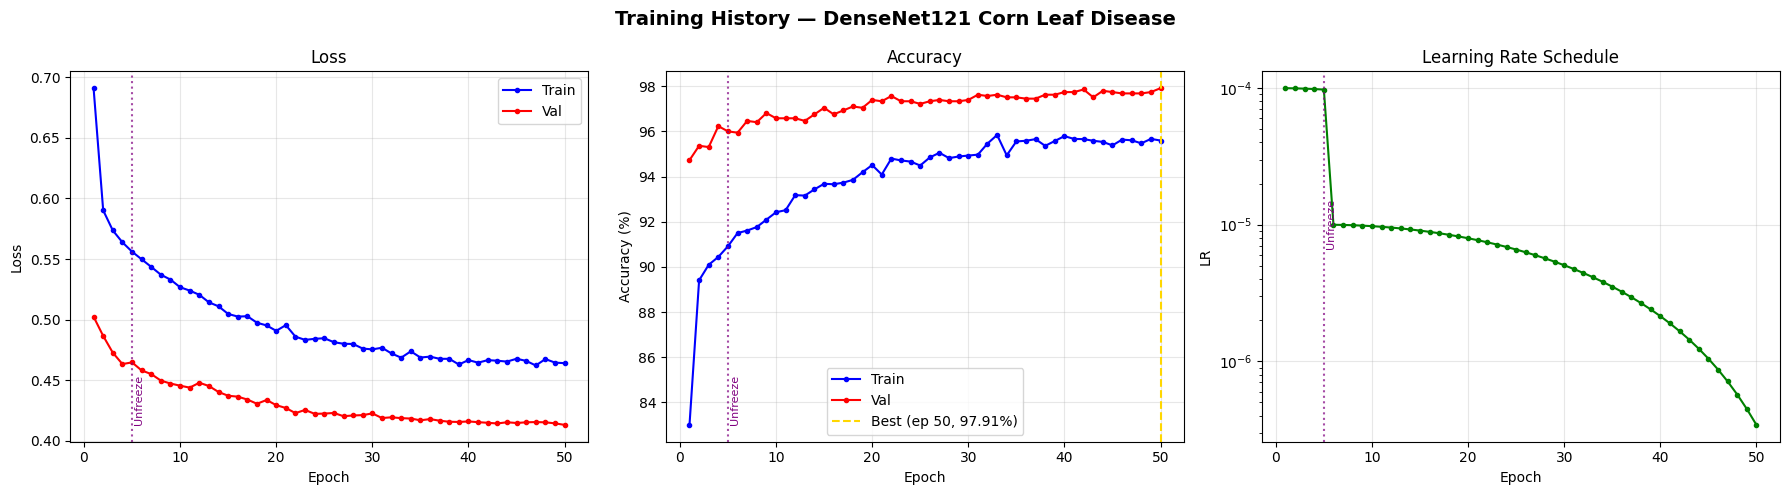


📊 Training Summary:
   Best Val Loss : 0.4132  (epoch 50)
   Best Val Acc  : 97.91%  (epoch 50)
   Final Train   : loss=0.4641  acc=95.59%
   Final Val     : loss=0.4132   acc=97.91%


In [21]:
# ═══════════════════════════════════════════════════
# CELL 15 — Visualisasi Training History
# ═══════════════════════════════════════════════════
def plot_history(history, freeze_epochs=FREEZE_EPOCHS, out_dir=OUTPUT_DIR):
    epochs = range(1, len(history['train_loss']) + 1)
    best_e = int(np.argmax(history['val_acc'])) + 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Training History — DenseNet121 Corn Leaf Disease',
                 fontsize=14, fontweight='bold')

    # ── Loss ─────────────────────────────────────────
    ax = axes[0]
    ax.plot(epochs, history['train_loss'], 'b-o', label='Train', ms=3, lw=1.5)
    ax.plot(epochs, history['val_loss'],   'r-o', label='Val',   ms=3, lw=1.5)
    ax.set_title('Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

    # ── Accuracy ─────────────────────────────────────
    ax = axes[1]
    ax.plot(epochs, [a*100 for a in history['train_acc']], 'b-o', label='Train', ms=3, lw=1.5)
    ax.plot(epochs, [a*100 for a in history['val_acc']],   'r-o', label='Val',   ms=3, lw=1.5)
    ax.axvline(best_e, color='gold', ls='--', lw=1.5,
               label=f'Best (ep {best_e}, {max(history["val_acc"])*100:.2f}%)')
    ax.set_title('Accuracy')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(); ax.grid(alpha=0.3)

    # ── Learning Rate ─────────────────────────────────
    ax = axes[2]
    ax.plot(epochs, history['lr'], 'g-o', ms=3, lw=1.5)
    ax.set_title('Learning Rate Schedule')
    ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
    ax.set_yscale('log'); ax.grid(alpha=0.3)

    # ── Phase boundary ────────────────────────────────
    if freeze_epochs > 0 and freeze_epochs < len(list(epochs)):
        for ax in axes:
            ylims = ax.get_ylim()
            ax.axvline(freeze_epochs, color='purple', ls=':', lw=1.5, alpha=0.7)
            ax.text(freeze_epochs + 0.2, ylims[0] + (ylims[1]-ylims[0])*0.05,
                    'Unfreeze', color='purple', fontsize=8, rotation=90)

    plt.tight_layout()
    plt.savefig(f'{out_dir}/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n📊 Training Summary:")
    print(f"   Best Val Loss : {min(history['val_loss']):.4f}  (epoch {int(np.argmin(history['val_loss']))+1})")
    print(f"   Best Val Acc  : {max(history['val_acc'])*100:.2f}%  (epoch {best_e})")
    print(f"   Final Train   : loss={history['train_loss'][-1]:.4f}  acc={history['train_acc'][-1]*100:.2f}%")
    print(f"   Final Val     : loss={history['val_loss'][-1]:.4f}   acc={history['val_acc'][-1]*100:.2f}%")


plot_history(history)

✅ Best model dimuat: densenet121_corn_disease_best.pt
   Best val acc saat training: 97.91%

🔍 Evaluasi pada Test Set ...


Test:   0%|          | 0/58 [00:00<?, ?it/s]


🎯 Test Accuracy : 98.1957%
🎯 Test F1-Score : 98.1961%  (weighted)

📋 Classification Report:
              precision    recall  f1-score   support

 Bercak_Daun     0.9655    0.9561    0.9608       410
  Hawar_Daun     0.9606    0.9706    0.9656       477
  Karat_Daun     1.0000    0.9979    0.9990       477
       Sehat     1.0000    1.0000    1.0000       465

    accuracy                         0.9820      1829
   macro avg     0.9815    0.9812    0.9813      1829
weighted avg     0.9820    0.9820    0.9820      1829

📄 Report disimpan ke: /content/output/classification_report.txt


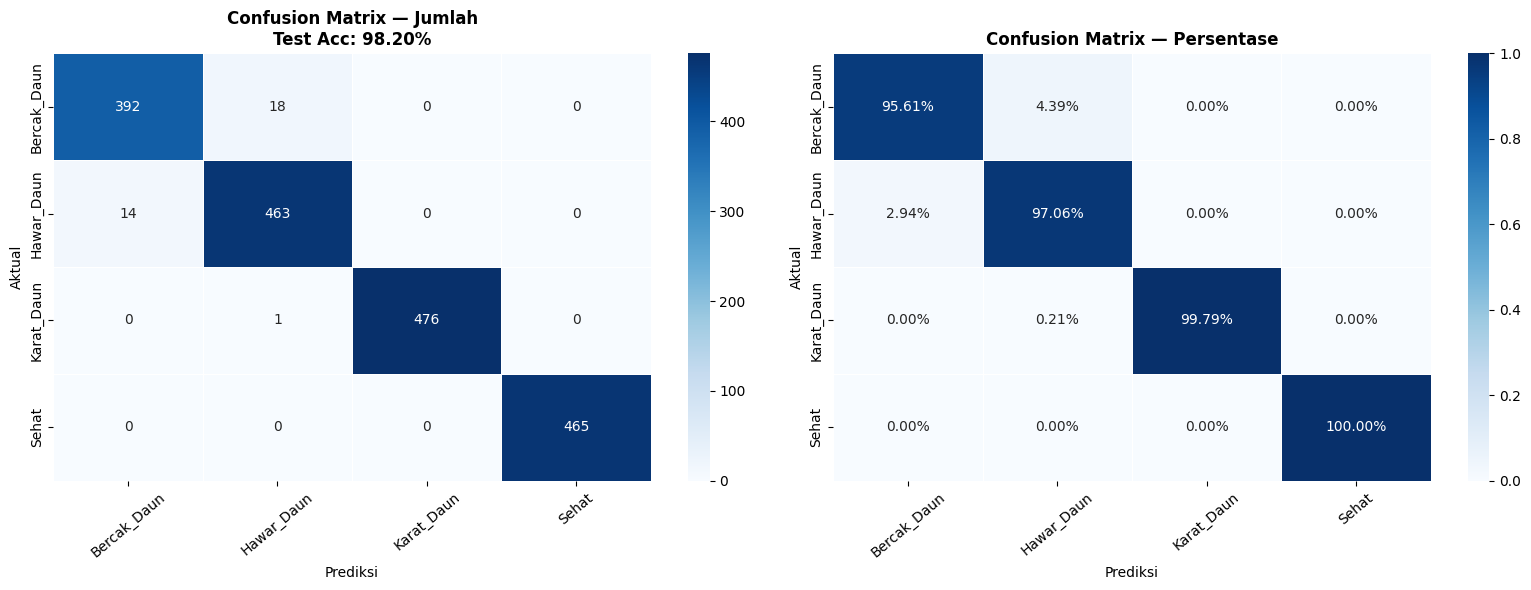

📊 Confusion matrix disimpan ke: /content/output/confusion_matrix.png

📊 Per-class Accuracy:
   Bercak_Daun                         ███████████████████  95.61%
   Hawar_Daun                          ███████████████████  97.06%
   Karat_Daun                          ███████████████████  99.79%
   Sehat                               ████████████████████ 100.00%


In [22]:
# ═══════════════════════════════════════════════════
# CELL 16 — Evaluasi Model pada Test Set
# ═══════════════════════════════════════════════════
def evaluate(model, test_loader, class_names, device, out_dir=OUTPUT_DIR):
    '''
    Evaluasi model pada test set.
    Output: Confusion Matrix (count & %) + Classification Report.
    Otomatis load best checkpoint jika ada.
    '''
    # ── Load best model ──────────────────────────────
    best_ckpt = Path(CHECKPOINT_DIR) / f'{CHECKPOINT_NAME}_best.pt'
    if best_ckpt.exists():
        state = torch.load(best_ckpt, map_location=device, weights_only=False)
        model.load_state_dict(state['model_state_dict'])
        print(f"✅ Best model dimuat: {best_ckpt.name}")
        print(f"   Best val acc saat training: {state['best_val_acc']*100:.2f}%")
    else:
        print("⚠️  Best checkpoint tidak ditemukan, menggunakan model di memory.")

    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    print("\n🔍 Evaluasi pada Test Set ...")

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Test'):
            inputs = inputs.to(device, non_blocking=True)
            logits = model(inputs)
            probs  = torch.softmax(logits, dim=1)
            preds  = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    # ── Overall accuracy ─────────────────────────────
    test_acc = accuracy_score(all_labels, all_preds)
    test_f1  = f1_score(all_labels, all_preds, average='weighted')
    print(f"\n{'='*70}")
    print(f"🎯 Test Accuracy : {test_acc*100:.4f}%")
    print(f"🎯 Test F1-Score : {test_f1*100:.4f}%  (weighted)")
    print(f"{'='*70}")

    # ── Classification report ─────────────────────────
    print("\n📋 Classification Report:")
    report = classification_report(all_labels, all_preds,
                                   target_names=class_names, digits=4)
    print(report)

    rpt_path = Path(out_dir) / 'classification_report.txt'
    rpt_path.write_text(
        f"Test Accuracy : {test_acc*100:.4f}%\n"
        f"Test F1-Score : {test_f1*100:.4f}%\n\n"
        f"Classification Report:\n{'='*70}\n{report}"
    )
    print(f"📄 Report disimpan ke: {rpt_path}")

    # ── Confusion Matrix ─────────────────────────────
    cm      = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(max(14, 4*len(class_names)), 6))

    kw = dict(xticklabels=class_names, yticklabels=class_names,
              linewidths=0.5, cmap='Blues')

    sns.heatmap(cm,      annot=True, fmt='d',    ax=axes[0], **kw)
    axes[0].set_title(f'Confusion Matrix — Jumlah\nTest Acc: {test_acc*100:.2f}%',
                      fontweight='bold')
    axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')
    axes[0].tick_params(axis='x', rotation=40)

    sns.heatmap(cm_norm, annot=True, fmt='.2%', ax=axes[1],
                vmin=0, vmax=1, **kw)
    axes[1].set_title('Confusion Matrix — Persentase', fontweight='bold')
    axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')
    axes[1].tick_params(axis='x', rotation=40)

    plt.tight_layout()
    cm_path = Path(out_dir) / 'confusion_matrix.png'
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"📊 Confusion matrix disimpan ke: {cm_path}")

    # ── Per-class accuracy ────────────────────────────
    print(f"\n📊 Per-class Accuracy:")
    for i, cls in enumerate(class_names):
        acc_i  = cm_norm[i, i] * 100
        bar    = '█' * int(acc_i / 5)
        print(f"   {cls:<35} {bar:<20} {acc_i:.2f}%")

    return {
        'test_accuracy'   : test_acc,
        'test_f1'         : test_f1,
        'confusion_matrix': cm,
        'predictions'     : all_preds,
        'labels'          : all_labels,
        'probabilities'   : all_probs,
    }


eval_results = evaluate(model, test_loader, CLASS_NAMES, DEVICE)

In [23]:
# ═══════════════════════════════════════════════════
# CELL 17 — Simpan Model Akhir
# ═══════════════════════════════════════════════════
# ── Konfigurasi ─────────────────────────────────────
SAVE_TO_DRIVE_FINAL = True        # Simpan copy ke Google Drive
DRIVE_MODEL_DIR     = '/content/drive/MyDrive/models/corn_disease'
FINAL_MODEL_NAME    = (
    f"densenet121_corn_{datetime.now().strftime('%Y%m%d_%H%M')}"
    f"_acc{eval_results['test_accuracy']*100:.1f}"
)


def export_model(model, class_names, out_dir, model_name,
                 drive_dir=None, eval_res=None):
    '''Export model ke berbagai format.'''
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    meta = {
        'arch'         : 'DenseNet121',
        'class_names'  : class_names,
        'num_classes'  : len(class_names),
        'image_size'   : IMAGE_SIZE,
        'imagenet_mean': IMAGENET_MEAN,
        'imagenet_std' : IMAGENET_STD,
        'hyperparams'  : {
            'dropout_rate' : DROPOUT_RATE,
            'learning_rate': LEARNING_RATE,
            'lr_backbone'  : LR_BACKBONE,
            'weight_decay' : WEIGHT_DECAY,
            'batch_size'   : BATCH_SIZE,
        },
        'test_accuracy': eval_res['test_accuracy'] if eval_res else None,
        'test_f1'      : eval_res['test_f1']       if eval_res else None,
        'trained_at'   : datetime.now().isoformat(),
    }

    saved_files = []

    # 1. Full checkpoint (untuk resume fine-tuning)
    ckpt_path = out / f'{model_name}_full_checkpoint.pt'
    torch.save({**meta, 'model_state_dict': model.state_dict(),
                'history': history}, ckpt_path)
    print(f"✅ Full checkpoint : {ckpt_path}")
    saved_files.append(ckpt_path)

    # 2. Weights only (inference ringan)
    w_path = out / f'{model_name}_weights.pth'
    torch.save(model.state_dict(), w_path)
    print(f"✅ Weights only    : {w_path}")
    saved_files.append(w_path)

    # 3. Metadata JSON
    json_path = out / f'{model_name}_metadata.json'
    json_path.write_text(json.dumps(meta, indent=2))
    print(f"✅ Metadata JSON   : {json_path}")
    saved_files.append(json_path)

    # 4. TorchScript (untuk deployment)
    try:
        example = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
        scripted = torch.jit.trace(model.eval(), example)
        ts_path = out / f'{model_name}_torchscript.pt'
        scripted.save(str(ts_path))
        print(f"✅ TorchScript     : {ts_path}")
        saved_files.append(ts_path)
    except Exception as e:
        print(f"⚠️  TorchScript gagal (opsional): {e}")

    # 5. Copy ke Google Drive
    if drive_dir:
        try:
            Path(drive_dir).mkdir(parents=True, exist_ok=True)
            for f in saved_files:
                dst = Path(drive_dir) / f.name
                shutil.copy2(f, dst)
                print(f"☁️  → Drive: {dst}")
        except Exception as e:
            print(f"⚠️  Gagal simpan ke Drive: {e}")

    print(f"\n{'='*60}")
    print(f"✅ Model berhasil diekspor!")
    print(f"   Nama       : {model_name}")
    print(f"   Test Acc   : {meta['test_accuracy']*100:.2f}%" if meta['test_accuracy'] else "")
    print(f"   Kelas      : {class_names}")
    print(f"{'='*60}")


# Reload best weights sebelum simpan
best_ckpt = Path(CHECKPOINT_DIR) / f'{CHECKPOINT_NAME}_best.pt'
if best_ckpt.exists():
    state = torch.load(best_ckpt, map_location=DEVICE, weights_only=False)
    model.load_state_dict(state['model_state_dict'])
    print("✅ Best weights dimuat sebelum export.\n")

export_model(
    model, CLASS_NAMES,
    out_dir=OUTPUT_DIR,
    model_name=FINAL_MODEL_NAME,
    drive_dir=DRIVE_MODEL_DIR if SAVE_TO_DRIVE_FINAL else None,
    eval_res=eval_results,
)

✅ Best weights dimuat sebelum export.

✅ Full checkpoint : /content/output/densenet121_corn_20260628_0817_acc98.2_full_checkpoint.pt
✅ Weights only    : /content/output/densenet121_corn_20260628_0817_acc98.2_weights.pth
✅ Metadata JSON   : /content/output/densenet121_corn_20260628_0817_acc98.2_metadata.json
✅ TorchScript     : /content/output/densenet121_corn_20260628_0817_acc98.2_torchscript.pt
☁️  → Drive: /content/drive/MyDrive/models/corn_disease/densenet121_corn_20260628_0817_acc98.2_full_checkpoint.pt
☁️  → Drive: /content/drive/MyDrive/models/corn_disease/densenet121_corn_20260628_0817_acc98.2_weights.pth
☁️  → Drive: /content/drive/MyDrive/models/corn_disease/densenet121_corn_20260628_0817_acc98.2_metadata.json
☁️  → Drive: /content/drive/MyDrive/models/corn_disease/densenet121_corn_20260628_0817_acc98.2_torchscript.pt

✅ Model berhasil diekspor!
   Nama       : densenet121_corn_20260628_0817_acc98.2
   Test Acc   : 98.20%
   Kelas      : ['Bercak_Daun', 'Hawar_Daun', 'Karat_Da

## ⚙️ KONFIGURASI INFERENSI
> Atur variabel di bawah, lalu jalankan **Cell 19**

| Variabel | Keterangan |
|----------|-----------|
| `INF_MODE` | `'single'` → 1 gambar, `'batch'` → banyak gambar |
| `INF_IMAGE` | Path gambar tunggal |
| `INF_BATCH` | List path gambar untuk batch |
| `INF_FOLDER` | Folder berisi gambar (jika batch) |
| `UPLOAD_IMAGE` | `True` → upload dari PC lokal |
| `USE_CURRENT_MODEL` | `True` → gunakan model di memory (tanpa load file) |

In [24]:
# ═══════════════════════════════════════════════════
# CELL 18 — Konfigurasi Inferensi
# ═══════════════════════════════════════════════════
# ── Mode ────────────────────────────────────────────
INF_MODE    = 'single'     # 'single' | 'batch'

# ── Path gambar ─────────────────────────────────────
INF_IMAGE   = '/content/test_image.jpg'          # untuk mode 'single'
INF_BATCH   = [                                   # untuk mode 'batch' (list)
    # '/content/img1.jpg',
    # '/content/img2.jpg',
]
INF_FOLDER  = ''    # Kosongkan atau isi folder path untuk mode 'batch'
                     # Semua gambar dalam folder akan diproses

# ── Upload dari lokal ────────────────────────────────
UPLOAD_IMAGE = True    # True = muncul dialog upload file

# ── Model ────────────────────────────────────────────
USE_CURRENT_MODEL = True    # True = gunakan model di memory
                             # False = load dari file (isi INF_MODEL_PATH)
INF_MODEL_PATH = ''          # Path file model jika USE_CURRENT_MODEL = False
                              # Contoh: f'{OUTPUT_DIR}/{FINAL_MODEL_NAME}_full_checkpoint.pt'

# ── Threshold ────────────────────────────────────────
CONFIDENCE_THRESHOLD = 0.5   # Prediksi < threshold → tampilkan peringatan

print("✅ Konfigurasi inferensi tersimpan.")
print(f"   Mode     : {INF_MODE}")
print(f"   Upload   : {UPLOAD_IMAGE}")
print(f"   Model    : {'Memory' if USE_CURRENT_MODEL else INF_MODEL_PATH}")

✅ Konfigurasi inferensi tersimpan.
   Mode     : single
   Upload   : True
   Model    : Memory


📂 Upload gambar:


Saving Karat-Daun-Sumber-Plantvillage.psu_.edu_-768x512.jpg to Karat-Daun-Sumber-Plantvillage.psu_.edu_-768x512 (1).jpg
✅ 1 gambar diupload: ['/content/Karat-Daun-Sumber-Plantvillage.psu_.edu_-768x512 (1).jpg']
✅ Best model dimuat untuk inferensi.


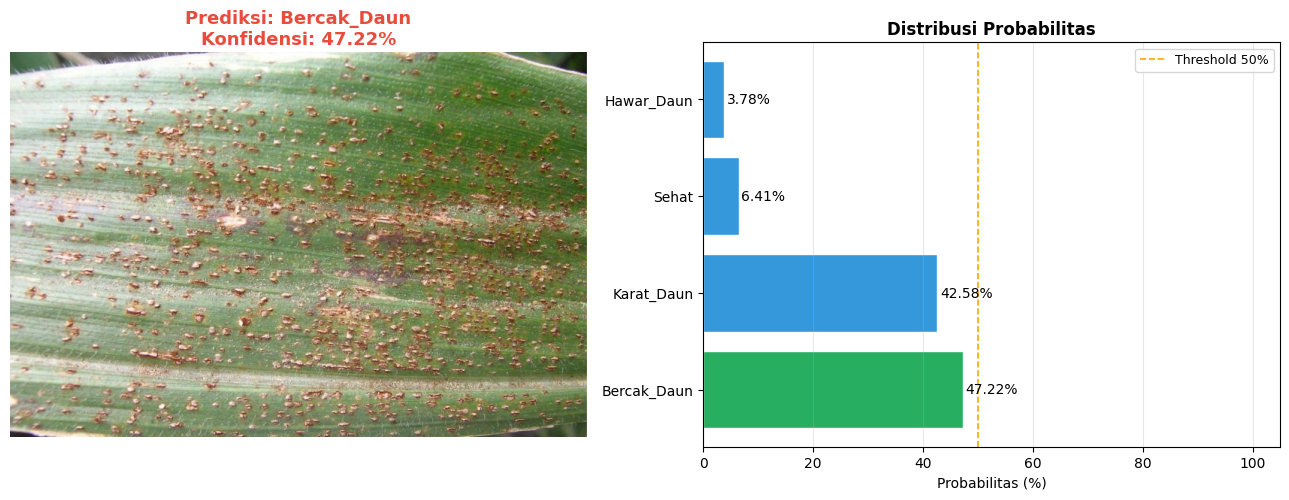


🌽 Hasil Deteksi Penyakit Daun Jagung:
   File        : Karat-Daun-Sumber-Plantvillage.psu_.edu_-768x512 (1).jpg
   Penyakit    : Bercak_Daun ⚠️ (konfidensі rendah!)
   Konfidensī  : 47.22%

   Semua Probabilitas:
   Bercak_Daun                         ███████████                47.22%
   Karat_Daun                          ██████████                 42.58%
   Sehat                               █                          6.41%
   Hawar_Daun                                                     3.78%


In [35]:
# ═══════════════════════════════════════════════════
# CELL 19 — Inferensi Gambar Baru
# ═══════════════════════════════════════════════════
# ── Inference transform ──────────────────────────────
inf_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def load_inference_model(model_path: str):
    '''Load model dari file untuk inferensi.'''
    state = torch.load(model_path, map_location=DEVICE, weights_only=False)
    class_names = state.get('class_names', CLASS_NAMES)
    num_classes  = state.get('num_classes',  NUM_CLASSES)

    m = build_densenet121(num_classes, dropout=DROPOUT_RATE).to(DEVICE)
    if 'model_state_dict' in state:
        m.load_state_dict(state['model_state_dict'])
    else:
        m.load_state_dict(state)
    m.eval()
    print(f"✅ Model dimuat dari: {model_path}")
    return m, class_names


@torch.no_grad()
def predict_one(inf_model, img_path: str, class_names: list,
                show: bool = True, out_dir: str = OUTPUT_DIR):
    '''Prediksi satu gambar dan tampilkan hasilnya.'''
    img        = Image.open(img_path).convert('RGB')
    tensor     = inf_tf(img).unsqueeze(0).to(DEVICE)
    logits     = inf_model(tensor)
    probs      = torch.softmax(logits, dim=1)[0].cpu().numpy()
    pred_idx   = int(probs.argmax())
    pred_class = class_names[pred_idx]
    confidence = float(probs[pred_idx])

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        # Gambar asli
        axes[0].imshow(img)
        color = '#27ae60' if confidence >= 0.7 else \
                '#f39c12' if confidence >= CONFIDENCE_THRESHOLD else '#e74c3c'
        axes[0].set_title(
            f"Prediksi: {pred_class}\nKonfidensі: {confidence*100:.2f}%",
            color=color, fontweight='bold', fontsize=13
        )
        axes[0].axis('off')

        # Bar chart probabilitas
        sorted_idx  = np.argsort(probs)[::-1]
        sorted_cls  = [class_names[i] for i in sorted_idx]
        sorted_prob = probs[sorted_idx] * 100
        bar_colors  = ['#27ae60' if c == pred_class else '#3498db' for c in sorted_cls]

        bars = axes[1].barh(sorted_cls, sorted_prob, color=bar_colors, edgecolor='white')
        axes[1].set_xlim(0, 105)
        axes[1].set_xlabel('Probabilitas (%)')
        axes[1].set_title('Distribusi Probabilitas', fontweight='bold')
        axes[1].axvline(CONFIDENCE_THRESHOLD * 100, color='orange',
                        ls='--', lw=1.2, label=f'Threshold {CONFIDENCE_THRESHOLD*100:.0f}%')
        axes[1].legend(fontsize=9)
        axes[1].grid(axis='x', alpha=0.3)

        for bar, pct in zip(bars, sorted_prob):
            axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                         f'{pct:.2f}%', va='center', fontsize=10)

        plt.tight_layout()
        plt.savefig(f'{out_dir}/inference_single.png', dpi=150, bbox_inches='tight')
        plt.show()

    # Console output
    warn = ' ⚠️ (konfidensі rendah!)' if confidence < CONFIDENCE_THRESHOLD else ''
    print(f"\n🌽 Hasil Deteksi Penyakit Daun Jagung:")
    print(f"   File        : {Path(img_path).name}")
    print(f"   Penyakit    : {pred_class}{warn}")
    print(f"   Konfidensī  : {confidence*100:.2f}%")
    print(f"\n   Semua Probabilitas:")
    for i in np.argsort(probs)[::-1]:
        bar = '█' * int(probs[i] * 25)
        print(f"   {class_names[i]:<35} {bar:<26} {probs[i]*100:.2f}%")

    return {'class': pred_class, 'confidence': confidence,
            'all_probs': {class_names[i]: float(probs[i])
                          for i in range(len(class_names))}}


@torch.no_grad()
def predict_batch_imgs(inf_model, img_paths: list, class_names: list,
                        out_dir: str = OUTPUT_DIR):
    '''Prediksi banyak gambar dan tampilkan grid hasil.'''
    n = len(img_paths)
    n_cols = min(4, n)
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    results = []
    print(f"🔍 Inferensi {n} gambar ...")

    for i, img_path in enumerate(img_paths):
        img      = Image.open(img_path).convert('RGB')
        tensor   = inf_tf(img).unsqueeze(0).to(DEVICE)
        logits   = inf_model(tensor)
        probs    = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred_idx = int(probs.argmax())
        conf     = float(probs[pred_idx])
        pred_cls = class_names[pred_idx]

        color = '#27ae60' if conf >= 0.7 else \
                '#f39c12' if conf >= CONFIDENCE_THRESHOLD else '#e74c3c'
        axes[i].imshow(img)
        axes[i].set_title(f"{pred_cls}\n{conf*100:.1f}%",
                          color=color, fontsize=9, fontweight='bold')
        axes[i].axis('off')

        results.append({'path': str(img_path), 'class': pred_cls,
                        'confidence': conf})
        marker = '⚠️' if conf < CONFIDENCE_THRESHOLD else '  '
        print(f"   {marker}[{i+1:2d}] {Path(img_path).name:<30}"
              f"→ {pred_cls:<35} ({conf*100:.1f}%)")

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Hasil Deteksi — {n} Gambar', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{out_dir}/inference_batch.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Ringkasan
    counts = Counter(r['class'] for r in results)
    print(f"\n📊 Ringkasan Prediksi Batch ({n} gambar):")
    for cls, cnt in counts.most_common():
        pct = cnt / n * 100
        print(f"   {cls:<35} : {cnt:3d} gambar  ({pct:.1f}%)")

    return results


# ══════════════════════════════════════════════════
# ── Jalankan Inferensi ─────────────────────────────
# ══════════════════════════════════════════════════

# 1. Upload gambar (opsional)
if UPLOAD_IMAGE:
    from google.colab import files
    print("📂 Upload gambar:")
    uploaded = files.upload()
    up_paths = []
    for fname, fdata in uploaded.items():
        p = f'/content/{fname}'
        Path(p).write_bytes(fdata)
        up_paths.append(p)
    print(f"✅ {len(up_paths)} gambar diupload: {up_paths}")
    if INF_MODE == 'single':
        INF_IMAGE = up_paths[0]
    else:
        INF_BATCH = up_paths

# 2. Load model
if USE_CURRENT_MODEL:
    best_ckpt = Path(CHECKPOINT_DIR) / f'{CHECKPOINT_NAME}_best.pt'
    if best_ckpt.exists():
        state = torch.load(best_ckpt, map_location=DEVICE, weights_only=False)
        model.load_state_dict(state['model_state_dict'])
        print("✅ Best model dimuat untuk inferensi.")
    inf_model   = model
    inf_classes = CLASS_NAMES
else:
    assert INF_MODEL_PATH and os.path.exists(INF_MODEL_PATH), \
        f"File model tidak ditemukan: {INF_MODEL_PATH}"
    inf_model, inf_classes = load_inference_model(INF_MODEL_PATH)

inf_model.eval()

# 3. Kumpulkan gambar untuk batch
if INF_MODE == 'batch':
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp',
                '.JPG', '.JPEG', '.PNG'}
    if INF_FOLDER and os.path.exists(INF_FOLDER):
        INF_BATCH = sorted([
            str(p) for p in Path(INF_FOLDER).rglob('*')
            if p.suffix in IMG_EXTS
        ])
        print(f"📁 Ditemukan {len(INF_BATCH)} gambar di folder: {INF_FOLDER}")
    INF_BATCH = [p for p in INF_BATCH if os.path.exists(p)]

# 4. Jalankan prediksi
if INF_MODE == 'single':
    if os.path.exists(INF_IMAGE):
        result = predict_one(inf_model, INF_IMAGE, inf_classes)
    else:
        print(f"❌ File tidak ditemukan: {INF_IMAGE}")
        print("   Atur UPLOAD_IMAGE = True atau perbaiki INF_IMAGE.")
elif INF_MODE == 'batch':
    if INF_BATCH:
        results = predict_batch_imgs(inf_model, INF_BATCH, inf_classes)
    else:
        print("❌ Tidak ada gambar untuk inferensi batch.")
        print("   Isi INF_BATCH atau INF_FOLDER, atau set UPLOAD_IMAGE = True.")